### Loading & Testing NLP Model

In [39]:
import requests
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
import json
import pandas as pd

In [40]:
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading spaCy model 'en_core_web_md'...")
    nlp = spacy.load("en_core_web_md")

In [41]:
nlp.add_pipe("spacytextblob")

doc = nlp("Argentina faces severe economic crisis")
print(doc._.blob.polarity)  # returns -1 to +1

0.2


### Testing Natural Language Processing (NLP)

In [42]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyser = SentimentIntensityAnalyzer()

def sentiment_score(text):

    scores = analyser.polarity_scores(text)
    compound = scores["compound"]

    if compound <= -0.6:
        label = "Very negative"
        score = 1
    elif compound <= -0.2:
        label = "Negative"
        score = 2
    elif compound < 0.2:
        label = "Neutral"
        score = 3
    elif compound < 0.6:
        label = "Positive"
        score = 4
    else:
        label = "Very positive"
        score = 5

    return {
        "label": label,
        "score": score,
        "compound": round(compound, 3),
        "details": scores
    }

example_headlines = ["UK borrowing costs hit highest since 2008 financial crisis. The interest rate on government debt is climbing over fears about inflation, interest rates",
                     "Stock markets surge and oil tumbles as Trump postpones power plant strikes after 'very good and productive' talks with Iran"]

for headline in example_headlines:
  print(headline)
  print(sentiment_score(headline))
  print("\n")

UK borrowing costs hit highest since 2008 financial crisis. The interest rate on government debt is climbing over fears about inflation, interest rates
{'label': 'Negative', 'score': 2, 'compound': -0.527, 'details': {'neg': 0.281, 'neu': 0.539, 'pos': 0.18, 'compound': -0.5267}}


Stock markets surge and oil tumbles as Trump postpones power plant strikes after 'very good and productive' talks with Iran
{'label': 'Neutral', 'score': 3, 'compound': -0.104, 'details': {'neg': 0.186, 'neu': 0.686, 'pos': 0.129, 'compound': -0.1045}}




### Creating & Populating the Database

In [43]:
import sqlite3
from pathlib import Path

DB_PATH = Path("../data/articles.db")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

def create_database(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS articles (
        article_id TEXT PRIMARY KEY,
        country TEXT,
        date TEXT,
        source_name TEXT,
        title TEXT,
        description TEXT,
        url TEXT,
        published_at TEXT
    )
    """)

    conn.commit()
    return conn, cursor

conn, cursor = create_database(DB_PATH)

In [44]:
# INSERT FUNCTION

def insert_articles(cursor, conn, articles):

    inserted = 0

    for a in articles:

        cursor.execute("""
            INSERT OR IGNORE INTO articles (
                article_id,
                country,
                date,
                source_name,
                title,
                description,
                url,
                published_at
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            a["article_id"],
            a["country"],
            a["date"],
            a["source_name"],
            a["title"],
            a["description"],
            a["url"],
            a["published_at"]
        ))

        inserted += cursor.rowcount

    conn.commit()

    print(f"  Inserted into DB: {inserted}")

In [45]:
# GUARDIAN FETCH FUNCTION

import requests

def fetch_guardian(country, begin_date, end_date, api_key):

    print("\nGUARDIAN FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print("Missing Guardian API key")
        return []

    url = "https://content.guardianapis.com/search"

    params = {
        "q": f"{country} economy",
        "section": "business",
        "from-date": begin_date,
        "to-date": end_date,
        "page-size": 200,
        "show-fields": "headline,trailText",
        "api-key": api_key
    }

    print("Requesting Guardian API...")

    response = requests.get(url, params=params)

    print(f"Status code: {response.status_code}")

    if response.status_code != 200:
        print("request failed")
        print(response.text)
        return []

    try:
        data = response.json()
    except Exception as e:
        print(f"JSON decode error: {e}")
        return []

    results = data.get("response", {}).get("results", [])

    print(f"Articles returned: {len(results)}")

    articles = []

    for article in results:

        fields = article.get("fields", {})

        published_at = article.get("webPublicationDate")

        parsed_article = {
            "article_id": article.get("id"),

            "country": country,

            # extract YYYY-MM-DD
            "date": published_at[:10] if published_at else None,

            "source_name": "The Guardian",

            "title": fields.get("headline"),

            "description": fields.get("trailText"),

            "url": article.get("webUrl"),

            "published_at": published_at
        }

        articles.append(parsed_article)

    print(f"   Parsed articles: {len(articles)}")

    return articles

In [46]:
import requests

NEWSAPI_ENDPOINT = "https://newsapi.org/v2/everything"

def fetch_newsapi(country, date_str, api_key):
    print("\n NEWSAPI FETCH START")
    print(f"   Country: {country}")
    print(f"   Date: {date_str}")

    if not api_key:
        print(" Missing NewsAPI key")
        return []

    query = f"{country} economy"

    params = {
        "q": query,
        "from": date_str,
        "to": date_str,
        "language": "en",
        "sortBy": "relevancy",
        "pageSize": 50,
        "apiKey": api_key
    }

    print(f"  Query: {query}")
    print(f"  Requesting NewsAPI...")

    response = requests.get(NEWSAPI_ENDPOINT, params=params)

    print(f"  Status code: {response.status_code}")

    if response.status_code != 200:
        print(f"  Error: {response.text}")
        return []

    data = response.json()

    articles = data.get("articles", [])
    print(f" Articles returned: {len(articles)}")

    formatted = []

    for i, a in enumerate(articles):
        formatted.append({
            "article_id": f"newsapi_{country}_{date_str}_{i}",
            "country": country,
            "date": date_str,
            "source_name": a.get("source", {}).get("name"),
            "title": a.get("title"),
            "description": a.get("description"),
            "url": a.get("url"),
            "published_at": a.get("publishedAt")
        })

    return formatted

In [47]:
# NYT FETCH FUNCTION (MONTH RANGE)
import requests

def fetch_nyt(country, begin_date, end_date, api_key):

    print("\n NYT FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print(" Missing NYT API key")
        return []

    url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

    params = {
        "q": f"{country} economy",
        "begin_date": begin_date,
        "end_date": end_date,
        "sort": "newest",
        "api-key": api_key
    }

    print(f"  Requesting NYT API...")

    response = requests.get(url, params=params)

    print(f" Status code: {response.status_code}")

    # ---- Rate limit handling ----
    if response.status_code == 429:
        print("  RATE LIMITED — skipping request")
        return []

    # ---- Bad response handling ----
    if response.status_code != 200:
        print("   Request failed")
        print(response.text)
        return []

    try:
        data = response.json()
    except Exception as e:
        print(f"  JSON decode error: {e}")
        return []

    docs = data.get("response", {}).get("docs", [])

    if docs is None:
        docs = []

    print(f"  Articles returned: {len(docs)}")

    articles = []

    for doc in docs:

        published_at = doc.get("pub_date")

        article = {
            "article_id": doc.get("_id"),

            "country": country,

            # extract YYYY-MM-DD
            "date": published_at[:10] if published_at else None,

            "source_name": "New York Times",

            "title": doc.get("headline", {}).get("main"),

            "description": doc.get("abstract"),

            "url": doc.get("web_url"),

            "published_at": published_at
        }

        articles.append(article)

    print(f"   Parsed articles: {len(articles)}")

    return articles

In [48]:
#cannot operate on a closed database
import sqlite3
from pathlib import Path

DB_PATH = Path("../data/articles.db")

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

In [49]:
# FULL INGESTION PIPELINE

from dotenv import load_dotenv
import os
import hashlib

load_dotenv()

# API KEYS
GUARDIAN_API_KEY = os.getenv("GUARDIAN_API_KEY")
NYT_API_KEY = os.getenv("NYT_API_KEY")
NEWSAPI_KEY = os.getenv("NEWSAPI_KEY")

# CONFIG
countries = ['Turkey', 'Argentina', 'India', 'Indonesia', 'Vietnam' , 'Nigeria']

begin_date_guardian = "2025-01-01"
end_date_guardian = "2026-05-01"

begin_date_nyt = "20250101"
end_date_nyt = "20260501"

begin_date_newsapi = "2025-01-01"
end_date_newsapi = "2026-05-01"

# ARTICLE ID 
def make_article_id(source, url):
    return hashlib.md5(f"{source}_{url}".encode()).hexdigest()


# INSERT FUNCTION (WITH LOGGING)
def insert_articles(cursor, conn, articles):
    inserted = 0
    skipped = 0

    for a in articles:
        try:
            cursor.execute("""
                INSERT OR IGNORE INTO articles (
                    article_id,
                    country,
                    date,
                    source_name,
                    title,
                    description,
                    url,
                    published_at
                ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """, (
                a["article_id"],
                a["country"],
                a["date"],
                a["source_name"],
                a["title"],
                a["description"],
                a["url"],
                a["published_at"]
            ))

            if cursor.rowcount == 0:
                skipped += 1
            else:
                inserted += 1

        except Exception as e:
            print("Insert error:", e)

    conn.commit()

    print(f" Inserted: {inserted} | Skipped (duplicates): {skipped}")


# =============================
# PIPELINE START
# =============================

print("Starting article ingestion pipeline...\n")

for country in countries:

    print("\n" + "=" * 60)
    print(f" COUNTRY: {country}")
    print("=" * 60)

    # -----------------------------
    # GUARDIAN
    # -----------------------------
    guardian_articles = fetch_guardian(
        country,
        begin_date_guardian,
        end_date_guardian,
        GUARDIAN_API_KEY
    )

    # standardise IDs
    for a in guardian_articles:
        a["article_id"] = make_article_id("guardian", a["url"])

    print(f" Guardian fetched: {len(guardian_articles)}")
    insert_articles(cursor, conn, guardian_articles)

    # -----------------------------
    # NEW YORK TIMES
    # -----------------------------
    nyt_articles = fetch_nyt(
        country,
        begin_date_nyt,
        end_date_nyt,
        NYT_API_KEY
    )

    for a in nyt_articles:
        a["article_id"] = make_article_id("nyt", a["url"])

    print(f" NYT fetched: {len(nyt_articles)}")
    insert_articles(cursor, conn, nyt_articles)

    # -----------------------------
    # NEWSAPI
    # -----------------------------
    newsapi_articles = fetch_newsapi(
        country,
        begin_date_newsapi,
        NEWSAPI_KEY
    )

    for a in newsapi_articles:
        a["article_id"] = make_article_id("newsapi", a["url"])

    print(f" NewsAPI fetched: {len(newsapi_articles)}")
    insert_articles(cursor, conn, newsapi_articles)

    print(f" Finished processing {country}")

print("\n ALL INGESTION COMPLETE!")

Starting article ingestion pipeline...


 COUNTRY: Turkey

GUARDIAN FETCH START
   Country: Turkey
   Range: 2025-01-01 → 2026-05-01
Requesting Guardian API...
Status code: 200
Articles returned: 200
   Parsed articles: 200
 Guardian fetched: 200
 Inserted: 53 | Skipped (duplicates): 147

 NYT FETCH START
   Country: Turkey
   Range: 20250101 → 20260501
  Requesting NYT API...
 Status code: 200
  Articles returned: 10
   Parsed articles: 10
 NYT fetched: 10
 Inserted: 10 | Skipped (duplicates): 0

 NEWSAPI FETCH START
   Country: Turkey
   Date: 2025-01-01
  Query: Turkey economy
  Requesting NewsAPI...
  Status code: 426
  Error: {"status":"error","code":"parameterInvalid","message":"You are trying to request results too far in the past. Your plan permits you to request articles as far back as 2026-04-04, but you have requested 2025-01-01. You may need to upgrade to a paid plan."}
 NewsAPI fetched: 0
 Inserted: 0 | Skipped (duplicates): 0
 Finished processing Turkey

 COUNTRY: Argenti

### Querying the SQLite Database

In [50]:
conn = sqlite3.connect("../data/articles.db")

query = "SELECT DISTINCT country FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

     country
0  Argentina
1      India
2  Indonesia
3    Nigeria
4     Turkey
5    Vietnam


In [51]:
conn = sqlite3.connect("../data/articles.db")

query = "SELECT * FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

                                            article_id  country        date  \
0    business/live/2026/jan/02/uk-house-prices-drop...    India  2026-01-02   
1    business/2026/jan/06/jaguar-land-rover-sales-u...    India  2026-01-06   
2    business/live/2026/jan/06/jlr-sales-hit-by-cyb...    India  2026-01-06   
3    business/2026/jan/06/bank-of-england-venezuela...  Vietnam  2026-01-06   
4    business/2026/jan/08/shadow-fleet-ships-sancti...   Turkey  2026-01-08   
..                                                 ...      ...         ...   
524                   fce329a4f9fe5f519906d8b712e67422  Nigeria  2026-04-07   
525                   2972ce9d89219336da281bed7d89b27d  Nigeria  2026-03-31   
526                   7fb8709220a1a06a2d3e96dbd05f7def  Nigeria  2026-03-20   
527                   46d086bdf9eba3bf84e2eec477213734  Nigeria  2026-03-18   
528                   e4ae388f91ff9ed9405e9cfab5b72b64  Nigeria  2026-03-05   

        source_name                                

In [52]:

conn = sqlite3.connect("../data/articles.db")

table_name = "articles"

query = f"""
PRAGMA table_info({table_name});
"""

df_columns = pd.read_sql_query(query, conn)

print(df_columns)

conn.close()

   cid             name  type  notnull dflt_value  pk
0    0       article_id  TEXT        0       None   1
1    1          country  TEXT        0       None   0
2    2             date  TEXT        0       None   0
3    3      source_name  TEXT        0       None   0
4    4            title  TEXT        0       None   0
5    5      description  TEXT        0       None   0
6    6              url  TEXT        0       None   0
7    7     published_at  TEXT        0       None   0
8    8  sentiment_score  REAL        0       None   0


In [ ]:
import sqlite3
import pandas as pd
from textblob import TextBlob

# Connect to database
conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()

# Add sentiment_score column if it doesn't 

try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_score REAL
    """)
    
    conn.commit()
    print("sentiment_score column created.")

except sqlite3.OperationalError:
    print("sentiment_score column already exists.")

# ---------------------------------------------------
# Load article IDs and titles
# ---------------------------------------------------

query = """
SELECT article_id, title
FROM articles
"""

df_articles = pd.read_sql_query(query, conn)

# ---------------------------------------------------
# Sentiment analysis function
# ---------------------------------------------------

def sentiment_analysis(text):
    
    if pd.isna(text):
        return None

    sentiment = TextBlob(text).sentiment.polarity
    
    return sentiment

# ---------------------------------------------------
# Apply sentiment analysis to every title
# and write back into the database
# ---------------------------------------------------

for _, row in df_articles.iterrows():

    article_id = row["article_id"]
    title = row["title"]

    sentiment_score = sentiment_analysis(title)

    cursor.execute("""
    UPDATE articles
    SET sentiment_score_vader = ?
    WHERE article_id = ?
    """, (sentiment_score, article_id))

# Save changes
conn.commit()

print("All sentiment scores written to database.")

# ---------------------------------------------------
# Optional check
# ---------------------------------------------------

check_query = """
SELECT title, sentiment_score, date, country
FROM articles
"""

df_plot = pd.read_sql_query(check_query, conn)

print(df_plot)

conn.close()

sentiment_score column already exists.
All sentiment scores written to database.
                                                 title  sentiment_score  \
0    FTSE 100 hits 10,000 point milestone for first...            0.625   
1    Jaguar Land Rover sales slump sharply amid US ...           -0.125   
2    FTSE 100 posts best day in six months as stock...            1.000   
3    Deep in the vaults: the Bank of England’s £1.4...            0.000   
4    ‘Shadow fleet’ ships moving sanctioned oil ref...            0.000   
..                                                 ...              ...   
524               How Much Humiliation Can Vance Take?            0.200   
525  For the Global Economy, ‘All Roads Lead to Hig...            0.125   
526         We’re All Living in the ‘Mirror World’ Now            0.000   
527                               Changing How We Vote            0.000   
528               Does the Iran War Put America First?            0.250   

           date  c

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot

,title,sentiment_score,date,country
0,"FTSE 100 hits 10,000 point milestone for first...",0.625,2026-01-02,India
1,Jaguar Land Rover sales slump sharply amid US ...,-0.125,2026-01-06,India
2,FTSE 100 posts best day in six months as stock...,1.000,2026-01-06,India
3,Deep in the vaults: the Bank of England’s £1.4...,0.000,2026-01-06,Vietnam
4,‘Shadow fleet’ ships moving sanctioned oil ref...,0.000,2026-01-08,Turkey
...,...,...,...,...
524,How Much Humiliation Can Vance Take?,0.200,2026-04-07,Nigeria
525,"For the Global Economy, ‘All Roads Lead to Hig...",0.125,2026-03-31,Nigeria
526,We’re All Living in the ‘Mirror World’ Now,0.000,2026-03-20,Nigeria
527,Changing How We Vote,0.000,2026-03-18,Nigeria


In [55]:
df_plot.dtypes

title                  str
sentiment_score    float64
date                   str
country                str
dtype: object

In [56]:
df_plot["date"] = pd.to_datetime(df_plot["date"])

In [57]:
df_plot.dtypes

title                         str
sentiment_score           float64
date               datetime64[us]
country                       str
dtype: object

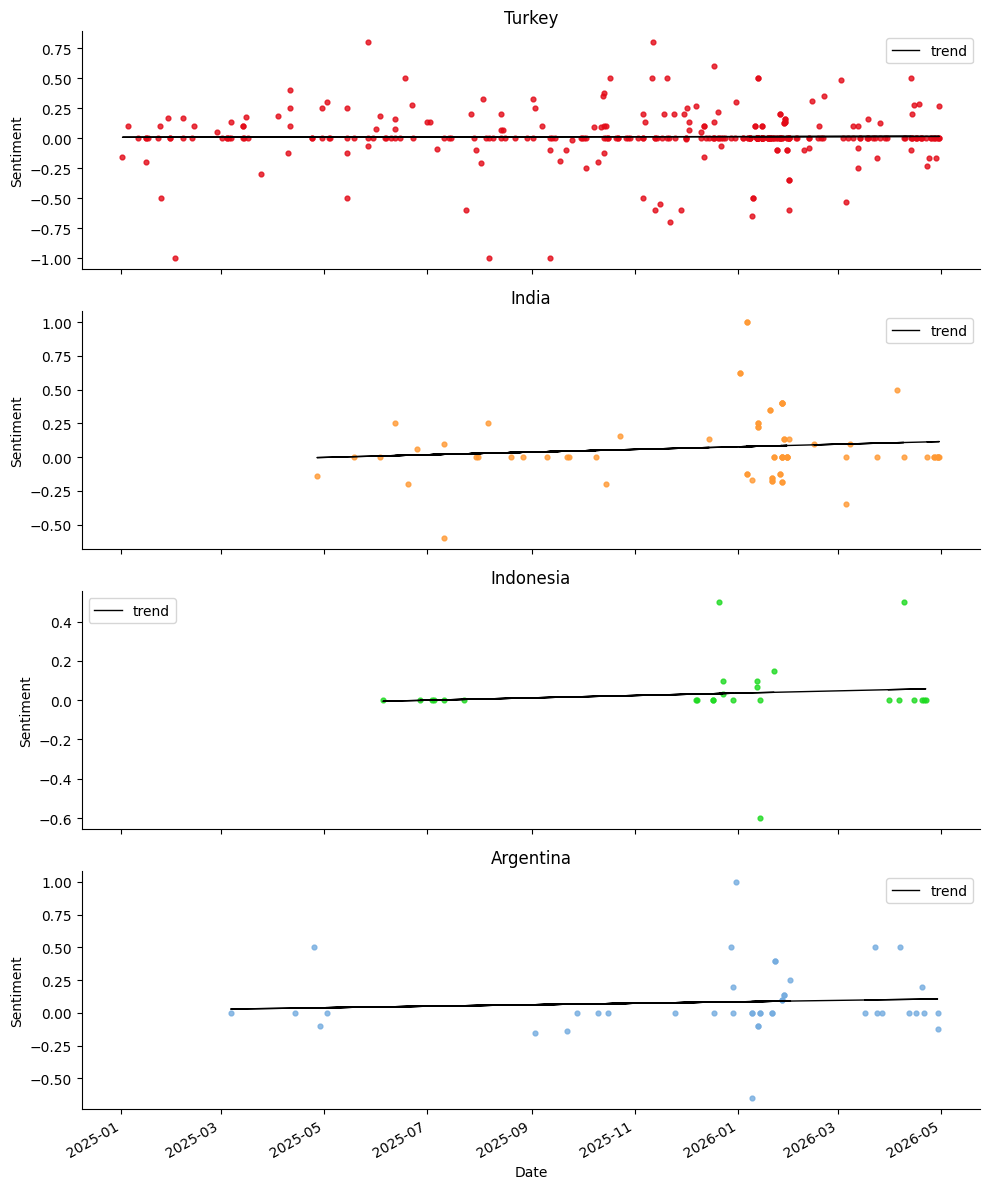

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

colors = {
    "Turkey": "#E30A17",
    "India": "#FF9933",
    "Indonesia": "#1DDA20",
    "Argentina": "#74ACDF",
   
}

countries = list(colors.keys())

fig, axes = plt.subplots(len(countries), 1, figsize=(10, 12), sharex=True)

for ax, country in zip(axes, countries):

    subset = df_plot[df_plot["country"] == country].dropna()

    # --- convert dates to numeric for regression ---
    x = pd.to_datetime(subset["date"])
    y = subset["sentiment_score"]

    x_numeric = x.map(pd.Timestamp.toordinal)

    # scatter plot
    ax.scatter(
        x,
        y,
        alpha=0.8,
        color=colors[country],
        s=12
    )

    # --- regression line ---
    if len(subset) > 1:
        slope, intercept = np.polyfit(x_numeric, y, 1)
        trend = slope * x_numeric + intercept

        ax.plot(
            x,
            trend,
            color="black",
            linewidth=1,
            linestyle="-",
            label="trend"
        )

    ax.set_title(country)
    ax.set_ylabel("Sentiment")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend()

axes[-1].set_xlabel("Date")
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [59]:
turkey = pd.read_csv("../data/turkey.csv")
turkey

,observation_date,CCUSMA02TRM618N
0,1957-01-01,0.000003
1,1957-02-01,0.000003
2,1957-03-01,0.000003
3,1957-04-01,0.000003
4,1957-05-01,0.000003
...,...,...
826,2025-11-01,42.240315
827,2025-12-01,42.645826
828,2026-01-01,43.161714
829,2026-02-01,43.647910


In [60]:
df_india = pd.read_csv("../data/india.csv")
df_india

,observation_date,DEXINUS
0,2021-04-26,74.75
1,2021-04-27,74.58
2,2021-04-28,74.49
3,2021-04-29,74.07
4,2021-04-30,74.00
...,...,...
1300,2026-04-20,93.13
1301,2026-04-21,93.50
1302,2026-04-22,93.79
1303,2026-04-23,94.11


In [61]:
df_indonesia = pd.read_csv("../data/indonesia.csv")
df_indonesia

,observation_date,CCUSMA02IDM618N
0,1967-01-01,137.000000
1,1967-02-01,137.000000
2,1967-03-01,137.000000
3,1967-04-01,137.000000
4,1967-05-01,137.000000
...,...,...
706,2025-11-01,16703.050000
707,2025-12-01,16707.130435
708,2026-01-01,16827.954545
709,2026-02-01,16825.700000


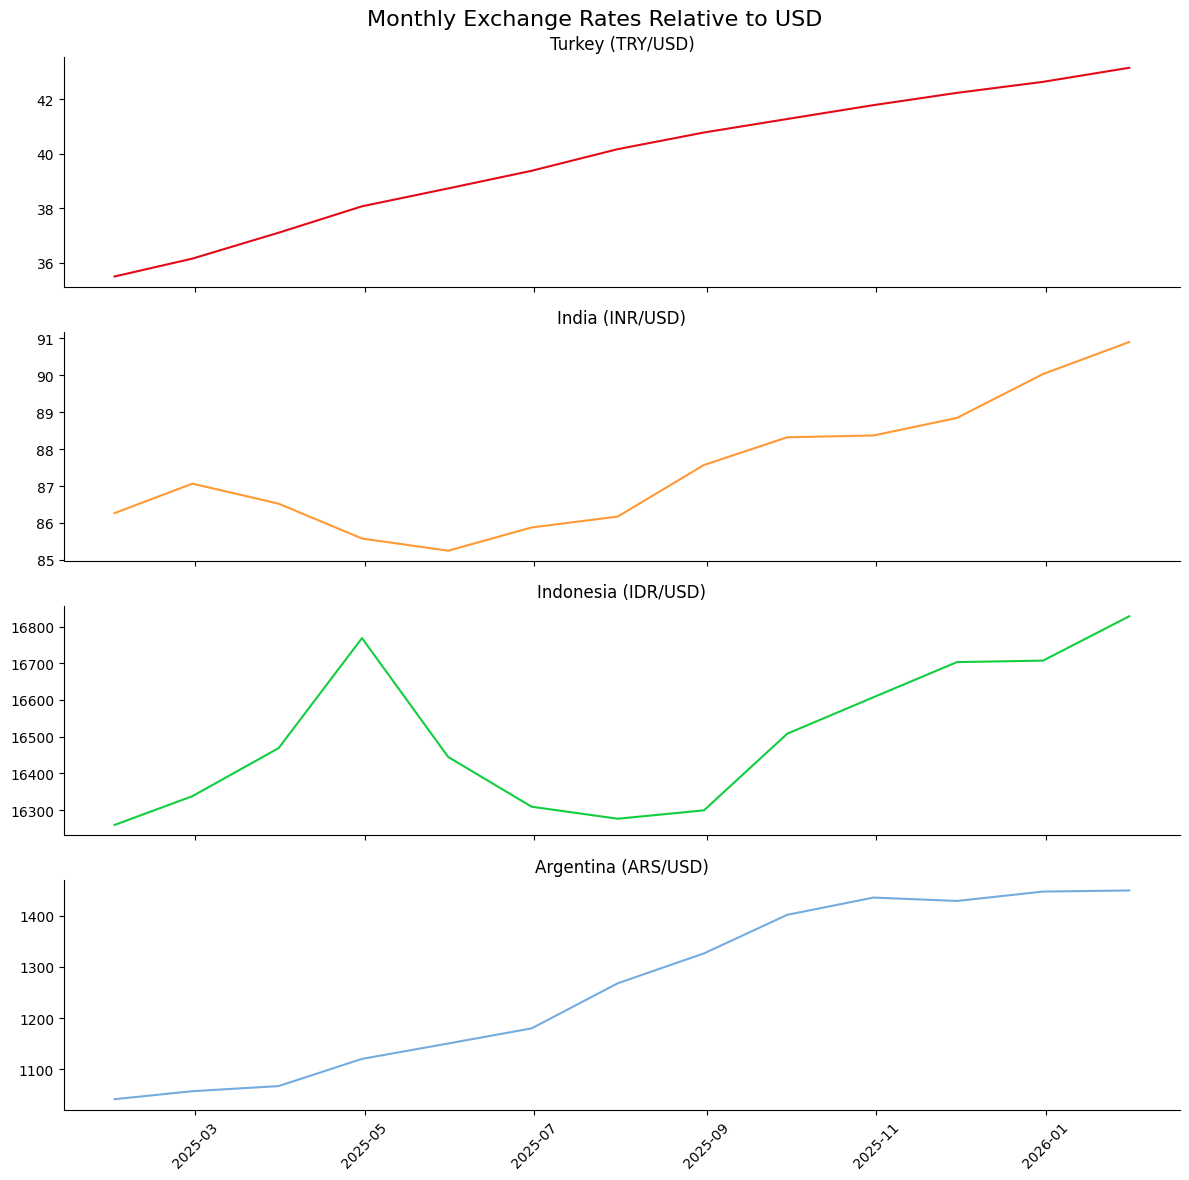

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load CSV files
# -----------------------------

df_turkey = pd.read_csv("../data/turkey.csv")
df_india = pd.read_csv("../data/india.csv")
df_indonesia = pd.read_csv("../data/indonesia.csv")
df_argentina = pd.read_csv("../data/argentina.csv")

# -----------------------------
# Convert dates
# -----------------------------

for df in [df_turkey, df_india, df_indonesia, df_argentina]:
    df["observation_date"] = pd.to_datetime(df["observation_date"])

# -----------------------------
# TIME FILTER
# -----------------------------

start_date = "2025-01-01"
end_date = "2026-02-01"

def filter_df(df):
    return df[
        (df["observation_date"] >= start_date) &
        (df["observation_date"] < end_date)
    ]

df_turkey = filter_df(df_turkey)
df_india = filter_df(df_india)
df_indonesia = filter_df(df_indonesia)
df_argentina = filter_df(df_argentina)

# -----------------------------
# RESAMPLE TO MONTHLY
# -----------------------------

def resample_df(df, col):
    return (
        df.set_index("observation_date")
        .resample("ME")
        .mean()
        .reset_index()
    )

df_turkey = resample_df(df_turkey, "CCUSMA02TRM618N")
df_india = resample_df(df_india, "DEXINUS")
df_indonesia = resample_df(df_indonesia, "CCUSMA02IDM618N")
df_argentina = resample_df(df_argentina, "ARGCCUSMA02STM")

# -----------------------------
# CREATE FIGURE WITH SUBPLOTS
# -----------------------------

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# -----------------------------
# Turkey
# -----------------------------
axes[0].plot(df_turkey["observation_date"], df_turkey["CCUSMA02TRM618N"],
             color="#E30A17")
axes[0].set_title("Turkey (TRY/USD)")

# -----------------------------
# India
# -----------------------------
axes[1].plot(df_india["observation_date"], df_india["DEXINUS"],
             color="#FF9933")
axes[1].set_title("India (INR/USD)")

# -----------------------------
# Indonesia
# -----------------------------
axes[2].plot(df_indonesia["observation_date"], df_indonesia["CCUSMA02IDM618N"],
             color="#11CE40")
axes[2].set_title("Indonesia (IDR/USD)")

# -----------------------------
# Argentina
# -----------------------------
axes[3].plot(df_argentina["observation_date"], df_argentina["ARGCCUSMA02STM"],
             color="#74ACDF")
axes[3].set_title("Argentina (ARS/USD)")

# -----------------------------
# Styling
# -----------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Monthly Exchange Rates Relative to USD", fontsize=16)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
df_argentina

,observation_date,ARGCCUSMA02STM
0,2025-01-31,1041.913043
1,2025-02-28,1057.537500
2,2025-03-31,1067.505952
3,2025-04-30,1120.619318
4,2025-05-31,1150.647727
5,2025-06-30,1180.130952
6,2025-07-31,1268.184783
7,2025-08-31,1326.500000
8,2025-09-30,1401.897727
9,2025-10-31,1435.489130


In [64]:
print(df_turkey["observation_date"].diff().value_counts().head())
print(df_india["observation_date"].diff().value_counts().head())

observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64


In [65]:
for name, df in {
    "Turkey": df_turkey,
    "India": df_india,
    "Indonesia": df_indonesia,
    "Argentina": df_argentina
}.items():

    print(name)
    print(df["observation_date"].diff().value_counts().head())
    print("-" * 40)

Turkey
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
India
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
Indonesia
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
Argentina
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------


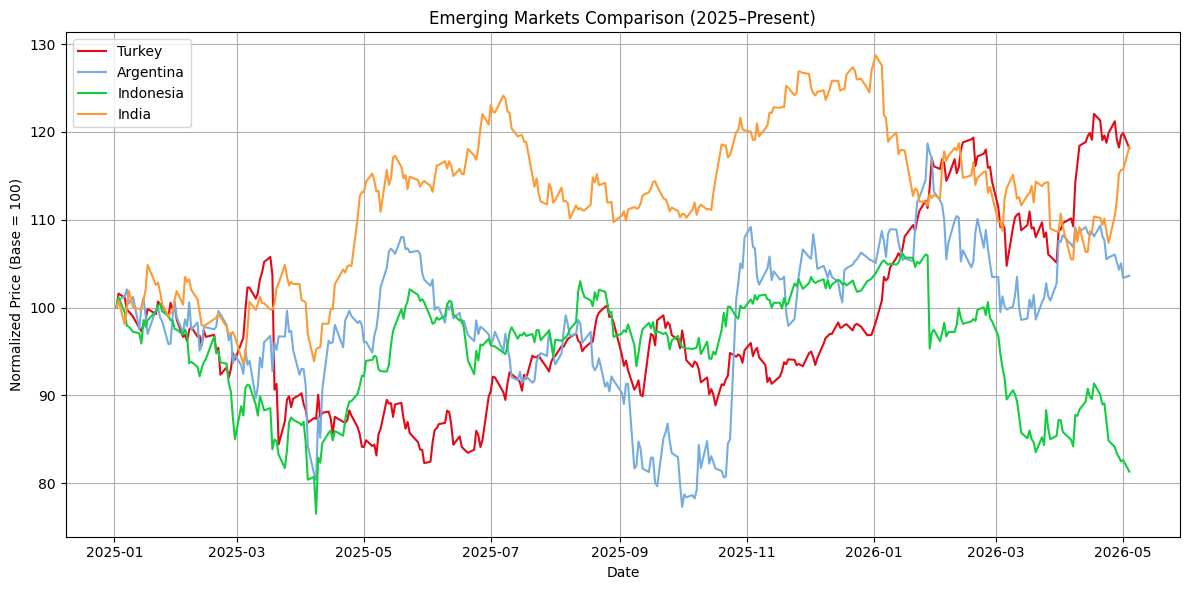

In [76]:
# -------------------------
# COLOUR SCHEME (MATCHED)
# -------------------------
colors = {
    "Turkey": "#E30A17",
    "India": "#FF9933",
    "Indonesia": "#11CE40",
    "Argentina": "#74ACDF"
}

# -------------------------
# FIGURE
# -------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# -------------------------
# PLOT
# -------------------------
for col in normalized.columns:
    ax.plot(
        normalized.index,
        normalized[col],
        label=col,
        color=colors[col]
    )

# -------------------------
# LABELS + STYLE
# -------------------------
ax.set_title("Emerging Markets Comparison (2025–Present)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 100)")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

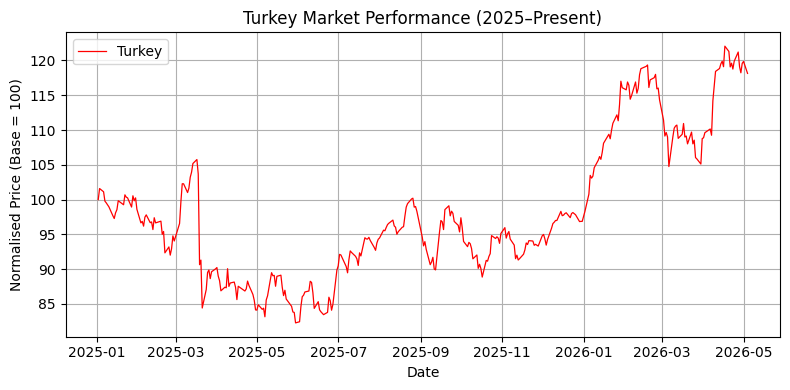

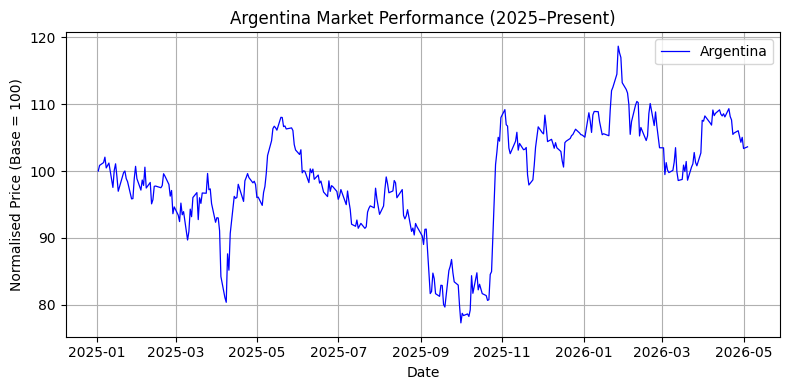

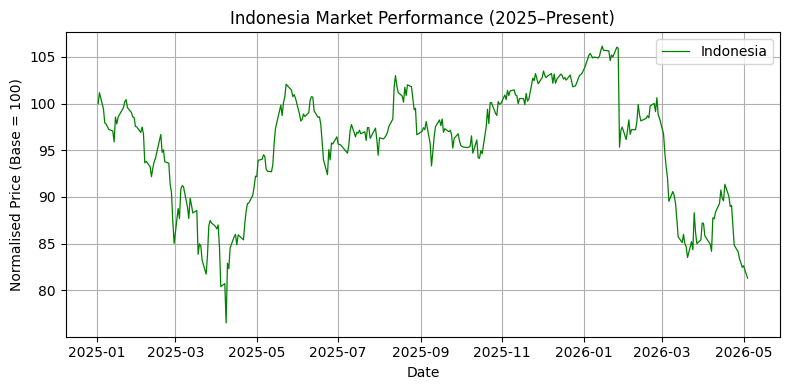

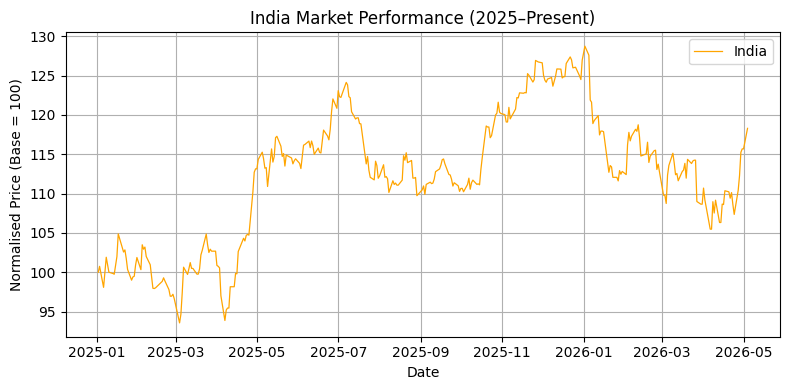

In [79]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# TICKERS
tickers = {
    "Turkey": "TUR",
    "Argentina": "ARGT",
    "Indonesia": "EIDO",
    "India": "RELIANCE.NS"
}

start_date = "2025-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

data = pd.DataFrame()

# -------------------------
# DOWNLOAD
# -------------------------
for name, ticker in tickers.items():
    print(f"Downloading {ticker}...")

    try:
        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            progress=False,
            timeout=10
        )

        if df.empty:
            print(f"No data for {ticker}")
            continue

        if "Adj Close" in df.columns:
            data[name] = df["Adj Close"]
        else:
            data[name] = df["Close"]

    except Exception as e:
        print(f"Failed for {ticker}: {e}")

if data.empty:
    raise ValueError("No data downloaded.")

# CLEAN + NORMALISE
data = data.ffill()
normalized = data / data.iloc[0] * 100

# CUSTOM COLOURS
colors = {
    "Turkey": "red",        
    "Argentina": "blue",   
    "Indonesia": "green",
    "India": "orange"         
}

# -------------------------
# SEPARATE PLOTS
# -------------------------
for country in normalized.columns:
    plt.figure(figsize=(8, 4))
    
    plt.plot(
        normalized.index,
        normalized[country],
        color=colors[country],
        label=country,
        linewidth=0.9
    )
    
    plt.title(f"{country} Market Performance (2025–Present)")
    plt.xlabel("Date")
    plt.ylabel("Normalised Price (Base = 100)")
    plt.legend()
    plt.grid(True)
    
    
    plt.tight_layout()
    plt.show()


In [80]:
from transformers import pipeline

finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

c:\Users\alice\Desktop\Uni\Econ\Data science for Econ\Final Project\fp-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\alice\Desktop\Uni\Econ\Data science for Econ\Final Project\fp-venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alice\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Dev

In [81]:
result = finbert("Turkey inflation falls faster than expected")

print(result)

[{'label': 'negative', 'score': 0.7823788523674011}]


In [86]:
conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()


query = "SELECT title FROM articles LIMIT 10"

df_test_finbert = pd.read_sql_query(query, conn)

print(df_test_finbert, "\n")

for rows in df_test_finbert["title"]:
    print(rows)
    print(finbert(rows))
    print("\n")

conn.close()

                                               title
0  FTSE 100 hits 10,000 point milestone for first...
1  Jaguar Land Rover sales slump sharply amid US ...
2  FTSE 100 posts best day in six months as stock...
3  Deep in the vaults: the Bank of England’s £1.4...
4  ‘Shadow fleet’ ships moving sanctioned oil ref...
5  Pub chain shares rise on reports of government...
6  US economy added fewer jobs than forecast in D...
7  High costs, falling returns: what could go wro...
8  Why Russia’s economy is unlikely to collapse e...
9  Trump move for Venezuela’s resources likely to... 

FTSE 100 hits 10,000 point milestone for first time, after best year of gains since 2009 – as it happened
[{'label': 'positive', 'score': 0.8794516324996948}]


Jaguar Land Rover sales slump sharply amid US tariffs and cyber-attack
[{'label': 'negative', 'score': 0.9734575748443604}]


FTSE 100 posts best day in six months as stock market rally continues – as it happened
[{'label': 'positive', 'score': 0.7235189